# HiProbCBM â€” Setup & Training di Colab (dataset CUB-200-2011)

Notebook ini menyiapkan CUB-200-2011 dan PseudoKitchens, lalu menjalankan HiProbCBM di Colab. Bagian 15-19 menyediakan alur klik-berurutan untuk protokol pembandingan terhadap hasil ProbCBM atau HiCEM yang dilaporkan.

**Struktur akhir yang dibutuhkan kode:**
```
datasets/CUB_200_2011/
  images/<kelas>/<file>.jpg      <- dari Drive kamu (raw CUB_200_2011)
  metadata/train.pkl             <- diambil dari repo HiCEM kalau belum ada di Drive
  metadata/val.pkl
  metadata/test.pkl
```

**Sebelum jalan:** edit `DRIVE_CUB_ROOT` di sel 2 supaya menunjuk ke folder `CUB_200_2011` di Drive kamu (yang isinya `images/`, `attributes/`, `bounding_boxes.txt`, dst â€” hasil download resmi Caltech).

## 1. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Set path ke folder CUB_200_2011 di Drive kamu

**Wajib diedit** â€” sesuaikan dengan lokasi folder di Drive kamu (klik kanan folder > Copy path, atau cek lewat sidebar Files).

In [3]:
import torch

print("CUDA tersedia:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Tidak terdeteksi")

CUDA tersedia: True
GPU: Tesla T4


In [4]:
import os

# TODO: sesuaikan path ini dengan lokasi folder CUB_200_2011 di Drive kamu
DRIVE_CUB_ROOT = "/content/drive/MyDrive/TESIS AZHIM/CUB_200_2011"

assert os.path.isdir(DRIVE_CUB_ROOT), f"Folder tidak ditemukan: {DRIVE_CUB_ROOT} -- cek lagi path-nya di sidebar Files Colab"
assert os.path.isdir(os.path.join(DRIVE_CUB_ROOT, "images")), "Folder 'images' tidak ada di dalam DRIVE_CUB_ROOT -- pastikan ini folder CUB_200_2011 yang benar"
print("OK, DRIVE_CUB_ROOT valid:", DRIVE_CUB_ROOT)

OK, DRIVE_CUB_ROOT valid: /content/drive/MyDrive/TESIS AZHIM/CUB_200_2011


## 3. Clone repo HiProbCBM & install

In [5]:
%cd /content
!test -d HiProbCBM || git clone https://github.com/Azhimanich/HiProbCBM.git
%cd /content/HiProbCBM
!pip install -e . -q

/content
Cloning into 'HiProbCBM'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 131 (delta 42), reused 120 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 92.34 KiB | 3.55 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/HiProbCBM
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for hiprobcbm (pyproject.toml) ... done


## 4. Siapkan metadata (train/val/test.pkl)

Kode `hiprobcbm/data/cub.py` butuh `metadata/train.pkl`, `val.pkl`, `test.pkl` (hasil preprocessing 112-konsep ala Koh dkk. 2020) di dalam `DRIVE_CUB_ROOT`.

- Kalau file itu **sudah** kamu upload ke Drive -> sel ini cuma skip, langsung dipakai.
- Kalau **belum** -> sel ini ambil otomatis dari repo referensi `HiCEM` (`OscarPi/cem-concept-discovery`, folder `splits/CUB/class_attr_data_10/`) dan menyimpannya ke Drive kamu supaya tidak perlu diulang tiap sesi Colab.

In [8]:
import pathlib, shutil

METADATA_DIR = pathlib.Path(DRIVE_CUB_ROOT) / "metadata"
NEEDED = ["train.pkl", "val.pkl", "test.pkl"]

missing = [f for f in NEEDED if not (METADATA_DIR / f).exists()]

if not missing:
    print("Metadata sudah lengkap di Drive, tidak perlu ambil ulang:", METADATA_DIR)
else:
    print("Belum lengkap, ambil dari HiCEM (GitHub). File yang kurang:", missing)
    %cd /content
    !test -d HiCEM_ref || git clone --depth 1 https://github.com/OscarPi/cem-concept-discovery.git HiCEM_ref
    METADATA_DIR.mkdir(parents=True, exist_ok=True)
    for f in missing:
        src = pathlib.Path("/content/HiCEM_ref/splits/CUB/class_attr_data_10") / f
        shutil.copy(src, METADATA_DIR / f)
        print("disalin:", src, "->", METADATA_DIR / f)
    %cd /content/HiProbCBM

Metadata sudah lengkap di Drive, tidak perlu ambil ulang: /content/drive/MyDrive/TESIS AZHIM/CUB_200_2011/metadata


## 5. Normalisasi `img_path` di dalam pkl

File pkl dari HiCEM/ProbCBM menyimpan `img_path` dengan prefix path lama dari server penulis paper aslinya (mis. `/juice/scr/.../CUB_200_2011/images/...`), bukan path relatif `<kelas>/<file>.jpg` yang diasumsikan `hiprobcbm/data/cub.py`. Sel ini membersihkan itu sekali saja, ditulis ulang ke Drive supaya tidak perlu diulang tiap sesi.

In [9]:
import pickle

MARKER = "CUB_200_2011/images/"

def normalize_img_path(p: str) -> str:
    return p.split(MARKER, 1)[1] if MARKER in p else p

for fname in NEEDED:
    fpath = METADATA_DIR / fname
    with open(fpath, "rb") as f:
        records = pickle.load(f)

    n_changed = sum(1 for r in records if MARKER in r["img_path"])
    if n_changed == 0:
        print(f"{fname}: sudah relatif, tidak ada yang diubah ({len(records)} record)")
        continue

    for r in records:
        r["img_path"] = normalize_img_path(r["img_path"])

    with open(fpath, "wb") as f:
        pickle.dump(records, f)
    print(f"{fname}: {n_changed}/{len(records)} img_path dinormalisasi & disimpan ulang ke Drive")

train.pkl: sudah relatif, tidak ada yang diubah (4796 record)
val.pkl: sudah relatif, tidak ada yang diubah (1198 record)
test.pkl: sudah relatif, tidak ada yang diubah (5794 record)


## 6. Rakit struktur `datasets/CUB_200_2011/` (symlink ke Drive, tanpa copy gambar)

In [10]:
import os

WORK_ROOT = pathlib.Path("/content/HiProbCBM/datasets/CUB_200_2011")
WORK_ROOT.parent.mkdir(parents=True, exist_ok=True)

if WORK_ROOT.is_symlink() or WORK_ROOT.exists():
    if WORK_ROOT.is_symlink():
        WORK_ROOT.unlink()
    else:
        raise RuntimeError(f"{WORK_ROOT} sudah ada dan bukan symlink -- cek manual dulu")

os.symlink(DRIVE_CUB_ROOT, WORK_ROOT, target_is_directory=True)
print("Symlink dibuat:", WORK_ROOT, "->", DRIVE_CUB_ROOT)

print("\nVerifikasi struktur:")
for sub in ["images", "metadata/train.pkl", "metadata/val.pkl", "metadata/test.pkl"]:
    p = WORK_ROOT / sub
    print(f"  [{'OK' if p.exists() else 'HILANG'}] {sub}")

Symlink dibuat: /content/HiProbCBM/datasets/CUB_200_2011 -> /content/drive/MyDrive/TESIS AZHIM/CUB_200_2011

Verifikasi struktur:
  [OK] images
  [OK] metadata/train.pkl
  [OK] metadata/val.pkl
  [OK] metadata/test.pkl


## 7. Sanity check â€” buka satu gambar contoh lewat pkl

Jumlah data train: 4796
img_path : 068.Ruby_throated_Hummingbird/Ruby_Throated_Hummingbird_0058_57298.jpg
kelas    : 67
n konsep : 112
Gambar berhasil dibuka, ukuran: (500, 326)


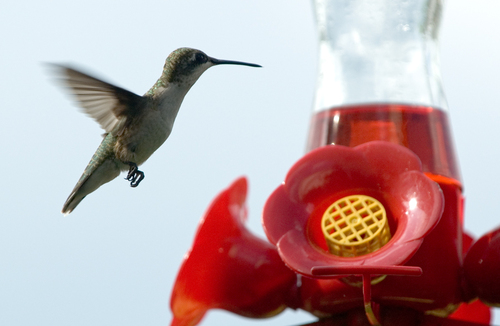

In [17]:
import random
from PIL import Image

with open(WORK_ROOT / "metadata" / "train.pkl", "rb") as f:
    train_records = pickle.load(f)

print("Jumlah data train:", len(train_records))
sample = random.choice(train_records)
print("img_path :", sample["img_path"])
print("kelas    :", sample["class_label"])
print("n konsep :", len(sample["attribute_label"]))

img_path = WORK_ROOT / "images" / sample["img_path"]
img = Image.open(img_path).convert("RGB")
print("Gambar berhasil dibuka, ukuran:", img.size)
img

## 8. Dry-run 2 batch data ASLI lewat model asli

**Kenapa perlu:** README `HiProbCBM` sendiri bilang repo ini baru diverifikasi lewat 34 *smoke test* dengan data sintetis di CPU â€” **belum pernah** dijalankan pada CUB-200-2011 asli. Sel #5 tadi sudah menemukan & memperbaiki 1 bug nyata (`img_path`). Supaya tidak baru ketahuan ada bug setelah training 50 epoch jalan berjam-jam, sel ini menjalankan 2 batch data asli lewat `HiProbCBMStage1` sungguhan (dipanggil langsung, bukan lewat CLI) dan mengecek loss/shape-nya masuk akal, sebelum commit ke training penuh.

In [11]:
import torch
from hiprobcbm.config import load_config, resolve_device
from hiprobcbm.data import build_dataset
from hiprobcbm.losses import hiprobcbm_stage1_loss
from hiprobcbm.models.hiprobcbm import HiProbCBMStage1

cfg = load_config("configs/cub_stage1.yaml")
device = resolve_device(0)
print("Device:", device)

dataset = build_dataset(cfg.dataset, **cfg.data.to_dict())
train_loader = dataset.get_dataloader("train", cfg.model.image_size, cfg.model.backbone, batch_size=4)

model = HiProbCBMStage1(
    backbone_name=cfg.model.backbone,
    num_concepts=dataset.num_concepts,
    concept_dim=cfg.model.concept_dim,
    pretrained=cfg.model.get("pretrained", True),
).to(device)

batch = next(iter(train_loader))
x = batch["image"].to(device)
c = batch["concepts"].to(device)
print("image batch shape :", x.shape)
print("concept batch shape:", c.shape, "(harus [batch, 112])")

out = model(x)
loss, components = hiprobcbm_stage1_loss(out.concept_probs, c, out.kl_loss, lambda_kl=cfg.train.get("lambda_kl", 5e-5))
loss.backward()

print("\nForward + backward SUKSES pada data asli.")
print("loss total:", loss.item(), "| komponen:", {k: v.item() for k, v in components.items()})
assert torch.isfinite(loss), "loss NaN/Inf -- cek learning rate / normalisasi data sebelum training penuh"

Device: cuda:0


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 104M/104M [00:00<00:00, 115MB/s]  
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


image batch shape : torch.Size([4, 3, 299, 299])
concept batch shape: torch.Size([4, 112]) (harus [batch, 112])

Forward + backward SUKSES pada data asli.
loss total: 0.7183167934417725 | komponen: {'concept_bce': 0.718251645565033, 'kl': 1.3028100728988647}


## 9. (Opsional) Jalankan smoke test dulu sebelum training penuh

In [ ]:
%cd /content/HiProbCBM
!pip install -e ".[dev]" -q
!python -m pytest tests/ -q

## 10. PseudoKitchens â€” cek folder sumber (raw)

Beda dari CUB, dataset PseudoKitchens di Drive kamu masih berupa **hasil generate mentah** (belum format siap-pakai `manifest.csv`/`info.json`). Sel ini cuma **mengecek struktur foldernya** â€” belum memproses apa pun â€” supaya kalau strukturnya tidak seperti yang diharapkan, ketahuan dari sini dulu, bukan gagal di tengah konversi yang bisa lama.

Format mentah yang diharapkan (dibaca `scripts/prepare_pseudokitchens_manifest.py`):
```
<raw_dir>/
  info.json
  train/001.png  001.json  001.exr
  val/...
  test/...
```

**Wajib diedit**: `PSEUDOKITCHENS_RAW_DIR` di bawah. Foldermu di Drive ada 2 (`pseudokitchens` dan `pseudokitchens-2`) â€” default saya arahkan ke `pseudokitchens-2` (mengikuti penamaan `_V2` di instruksi asli HiCEM), tapi **cek dulu isinya lewat output sel ini** sebelum lanjut, siapa tahu yang benar justru `pseudokitchens` (tanpa akhiran).

In [12]:
# TODO: sesuaikan kalau folder yang benar bukan pseudokitchens-2
PSEUDOKITCHENS_RAW_DIR = pathlib.Path("/content/drive/MyDrive/TESIS AZHIM/PseudoKitchens/pseudokitchens")

print("Mengecek:", PSEUDOKITCHENS_RAW_DIR)
print()

if not PSEUDOKITCHENS_RAW_DIR.is_dir():
    print("[HILANG] Folder tidak ditemukan -- cek path-nya lewat sidebar Files Colab.")
else:
    has_info = (PSEUDOKITCHENS_RAW_DIR / "info.json").exists()
    print(f"  [{'OK' if has_info else 'HILANG'}] info.json")
    for split in ("train", "val", "test"):
        split_dir = PSEUDOKITCHENS_RAW_DIR / split
        if split_dir.is_dir():
            n_png = len(list(split_dir.glob("*.png")))
            n_json = len(list(split_dir.glob("*.json")))
            n_exr = len(list(split_dir.glob("*.exr")))
            print(f"  [OK]     {split}/  -> {n_png} .png, {n_json} .json, {n_exr} .exr")
        else:
            print(f"  [HILANG] {split}/")
    print()
    print("Isi folder (top-level), buat cross-check manual kalau strukturnya beda dari dugaan:")
    for p in sorted(PSEUDOKITCHENS_RAW_DIR.iterdir())[:20]:
        tag = "(folder)" if p.is_dir() else f"({p.stat().st_size} bytes)"
        print(" -", p.name, tag)

Mengecek: /content/drive/MyDrive/TESIS AZHIM/PseudoKitchens/pseudokitchens

  [OK] info.json
  [OK]     train/  -> 10000 .png, 10000 .json, 10000 .exr
  [OK]     val/  -> 1000 .png, 1000 .json, 1000 .exr
  [OK]     test/  -> 1000 .png, 1000 .json, 1000 .exr

Isi folder (top-level), buat cross-check manual kalau strukturnya beda dari dugaan:
 - info.json (2945 bytes)
 - test (folder)
 - test.tar (489697280 bytes)
 - train (folder)
 - train.tar (4873564160 bytes)
 - val (folder)
 - val.tar (489543680 bytes)


## 11. PseudoKitchens â€” konversi ke manifest rata

Kalau sel #10 di atas menunjukkan `info.json` + `train/val/test` (`.png`+`.json`+`.exr`) sudah lengkap, sel ini menjalankan konversi satu kali lewat `scripts/prepare_pseudokitchens_manifest.py` â€” mengubahnya jadi `images/` + `manifest.csv` + `info.json` yang dibaca `hiprobcbm/data/kitchens.py`.

Ditulis **langsung ke Drive** (bukan ke `/content` dulu baru disalin manual) supaya persisten lintas sesi sejak awal â€” pelajaran dari insiden `train_log` sebelumnya, tidak diulang di sini.

Butuh paket `OpenEXR` (dependensi opsional, cuma dipakai sel ini, bukan oleh training/evaluasi sehari-hari). Proses bisa memakan waktu tergantung jumlah citra â€” **resumable**, otomatis di-skip kalau `manifest.csv` sudah ada di Drive.

In [18]:
DRIVE_KITCHENS_ROOT = pathlib.Path(DRIVE_CUB_ROOT).parent / "PseudoKitchens_processed"

if (DRIVE_KITCHENS_ROOT / "manifest.csv").exists():
    print("manifest.csv sudah ada di Drive, skip konversi:", DRIVE_KITCHENS_ROOT)
else:
    print("Install OpenEXR...")
    !pip install OpenEXR -q

    DRIVE_KITCHENS_ROOT.mkdir(parents=True, exist_ok=True)
    !python scripts/prepare_pseudokitchens_manifest.py \
        --raw-dir "{PSEUDOKITCHENS_RAW_DIR}" \
        --out-dir "{DRIVE_KITCHENS_ROOT}"

manifest.csv sudah ada di Drive, skip konversi: /content/drive/MyDrive/TESIS AZHIM/PseudoKitchens_processed


## 12. Rakit struktur `datasets/PseudoKitchens/` (symlink ke Drive)

Pola sama seperti sel #6 untuk CUB â€” symlink, tanpa menyalin ulang gambar.

In [19]:
KITCHENS_WORK_ROOT = pathlib.Path("/content/HiProbCBM/datasets/PseudoKitchens")
KITCHENS_WORK_ROOT.parent.mkdir(parents=True, exist_ok=True)

if KITCHENS_WORK_ROOT.is_symlink() or KITCHENS_WORK_ROOT.exists():
    if KITCHENS_WORK_ROOT.is_symlink():
        KITCHENS_WORK_ROOT.unlink()
    else:
        raise RuntimeError(f"{KITCHENS_WORK_ROOT} sudah ada dan bukan symlink -- cek manual dulu")

os.symlink(DRIVE_KITCHENS_ROOT, KITCHENS_WORK_ROOT, target_is_directory=True)
print("Symlink dibuat:", KITCHENS_WORK_ROOT, "->", DRIVE_KITCHENS_ROOT)

print("\nVerifikasi struktur:")
for sub in ["images", "info.json", "manifest.csv"]:
    p = KITCHENS_WORK_ROOT / sub
    print(f"  [{'OK' if p.exists() else 'HILANG'}] {sub}")

Symlink dibuat: /content/HiProbCBM/datasets/PseudoKitchens -> /content/drive/MyDrive/TESIS AZHIM/PseudoKitchens_processed

Verifikasi struktur:
  [OK] images
  [OK] info.json
  [OK] manifest.csv


## 13. Sanity check PseudoKitchens â€” buka satu gambar contoh lewat manifest

Jumlah baris manifest: 12000
Kolom: ['image', 'split', 'recipe', 'Apple', 'Banana', 'Butter', 'Carrot', 'Cheese', 'Chilli', 'Chocolate'] ...

Contoh baris:
img   : train/04874.png
split : train
recipe: Smoothie
Gambar berhasil dibuka, ukuran: (512, 512)


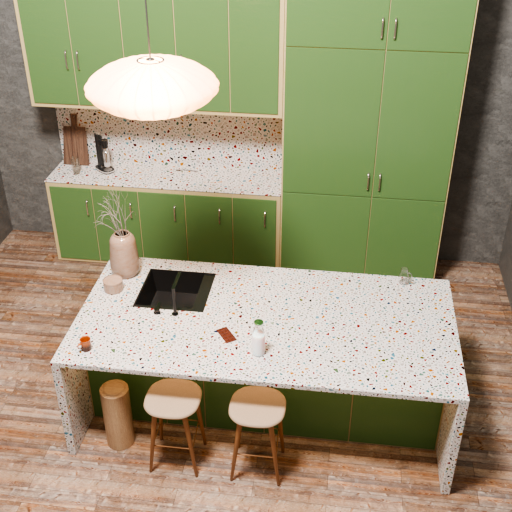

In [20]:
import pandas as pd

manifest = pd.read_csv(KITCHENS_WORK_ROOT / "manifest.csv")
print("Jumlah baris manifest:", len(manifest))
print("Kolom:", list(manifest.columns)[:10], "..." if len(manifest.columns) > 10 else "")

row = manifest.sample(1).iloc[0]
print("\nContoh baris:")
print("img   :", row["image"])  # format: "<split>/<file>.png", relatif ke images/
print("split :", row["split"])
print("recipe:", row["recipe"])

img_path = KITCHENS_WORK_ROOT / "images" / row["image"]
img = Image.open(img_path).convert("RGB")
print("Gambar berhasil dibuka, ukuran:", img.size)
img

## 14. Sambungkan `train_log/` ke Drive (persisten lintas sesi)

Jalankan sebelum sel 15, 16, atau 17. Disk `/content` hilang jika runtime dihapus/diganti; putus koneksi VS Code saja belum membuktikan runtime mati.
Checkpoint lengkap disimpan setiap akhir epoch training. SAE disimpan setiap 10 epoch dan akhir tiap konsep. Periksa pesan **CHECKPOINT SAVED** dan lokasi Drive.

Jika folder lokal sudah berisi hasil lama, arsipkan ke lokasi Drive baru sebelum membuat symlink. Jangan menimpa hasil lama. Bobot `*_best.pth`/`*_last.pth` dari kode lama tidak memuat optimizer, epoch, dan RNG sehingga bukan checkpoint resume lengkap.
Lihat `docs/resume_training.md` untuk pemulihan dan batas reproducibility.


In [21]:
assert pathlib.Path("/content/drive/MyDrive").is_dir(), "Mount Google Drive dahulu. Jangan menyimpan ke direktori Drive palsu di disk lokal."

TRAIN_LOG_DRIVE = pathlib.Path(DRIVE_CUB_ROOT).parent / "HiProbCBM_results" / "train_log"
TRAIN_LOG_DRIVE.mkdir(parents=True, exist_ok=True)

TRAIN_LOG_LOCAL = pathlib.Path("/content/HiProbCBM/train_log")
if TRAIN_LOG_LOCAL.is_symlink():
    TRAIN_LOG_LOCAL.unlink()
elif TRAIN_LOG_LOCAL.exists():
    raise RuntimeError(
        f"{TRAIN_LOG_LOCAL} sudah ada dan bukan symlink -- kemungkinan berisi hasil training asli. "
        "Backup dulu manual (lihat sel markdown di atas) sebelum menjalankan ulang sel ini."
    )

os.symlink(TRAIN_LOG_DRIVE, TRAIN_LOG_LOCAL, target_is_directory=True)
print("train_log/ tersambung ke Drive:", TRAIN_LOG_LOCAL, "->", TRAIN_LOG_DRIVE)
print("Semua checkpoint & pseudo_hierarchy.pt dari sini akan langsung masuk Drive, persisten lintas sesi.")

def assert_persistent_training_storage():
    assert pathlib.Path("/content/drive/MyDrive").is_dir(), "Google Drive belum mounted."
    assert TRAIN_LOG_LOCAL.is_symlink(), "Jalankan sel 14: train_log harus symlink ke Drive."
    assert TRAIN_LOG_LOCAL.resolve() == TRAIN_LOG_DRIVE.resolve(), "Target train_log berubah."
    assert TRAIN_LOG_DRIVE.resolve().is_relative_to(pathlib.Path("/content/drive/MyDrive")), "Checkpoint harus di Drive."

assert_persistent_training_storage()


train_log/ tersambung ke Drive: /content/HiProbCBM/train_log -> /content/drive/MyDrive/TESIS AZHIM/HiProbCBM_results/train_log
Semua checkpoint & pseudo_hierarchy.pt dari sini akan langsung masuk Drive, persisten lintas sesi.


## 15. Pilih protokol, variasi HiProbCBM, dan seed

Selesaikan sel 14 (penyimpanan log ke Drive) dahulu. Pada sel berikut, ubah hanya `PROTOKOL`, `VARIAN`, atau `SEED`; setelah itu tekan sel 15, 16, dan 17 berurutan.

- `PROTOKOL = "probcbm"`: CUB-200-2011 + ResNet18. Hasil utama dibandingkan dengan hasil ProbCBM yang dilaporkan.
- `PROTOKOL = "hicem"`: PseudoKitchens V2 + CLIP ViT-L/14. Hasil utama dibandingkan dengan hasil HiCEM yang dilaporkan.
- `VARIAN = "utama"`: HiProbCBM lengkap.
- `VARIAN = "a1"`: tanpa learned attention.
- `VARIAN = "a2"`: tanpa KL pada Tahap 2.
- `VARIAN = "a3"`: discovery memakai BatchTopK SAE.

Sel ini tidak menjalankan atau mengubah repository ProbCBM/HiCEM. Setiap seed dan variasi mempunyai folder log Drive terpisah. Jika koneksi putus, jalankan kembali sel setup sampai sel 15, lalu tekan sel training yang sama; `--resume auto` memvalidasi checkpoint sebelum melanjutkan.


In [ ]:
%cd /content/HiProbCBM
from pathlib import Path
from hiprobcbm.config import Config, load_config, prepare_log_dir

# Ubah tiga baris ini bila perlu.
PROTOKOL = "probcbm"  # "probcbm" untuk CUB/ResNet18, atau "hicem" untuk PseudoKitchens/CLIP
VARIAN = "utama"      # "utama", "a1", "a2", atau "a3"
SEED = 42

PROTOKOL_CONFIG = {
    "probcbm": {
        "nama": "ProbCBM reported: CUB-200-2011 + ResNet18",
        "stage1": "configs/cub_stage1_probcbm_reported.yaml",
        "stage2": "configs/cub_stage2_probcbm_reported.yaml",
        "stage1_a3": "configs/cub_stage1_probcbm_reported_batchtopk.yaml",
        "stage2_a3": "configs/cub_stage2_probcbm_reported_batchtopk.yaml",
        "baseline": "ProbCBM (hasil publikasi; tidak dijalankan ulang di notebook ini)",
    },
    "hicem": {
        "nama": "HiCEM reported: PseudoKitchens V2 + CLIP ViT-L/14",
        "stage1": "configs/kitchens_stage1_hicem_reported.yaml",
        "stage2": "configs/kitchens_stage2_hicem_reported.yaml",
        "stage1_a3": "configs/kitchens_stage1_hicem_reported_batchtopk.yaml",
        "stage2_a3": "configs/kitchens_stage2_hicem_reported_batchtopk.yaml",
        "baseline": "HiCEM (hasil publikasi; tidak dijalankan ulang di notebook ini)",
    },
}
assert PROTOKOL in PROTOKOL_CONFIG, "PROTOKOL harus 'probcbm' atau 'hicem'."
assert VARIAN in {"utama", "a1", "a2", "a3"}, "VARIAN harus utama, a1, a2, atau a3."
assert_persistent_training_storage()
PILIHAN = PROTOKOL_CONFIG[PROTOKOL]
STAGE1_CONFIG = PILIHAN["stage1_a3"] if VARIAN == "a3" else PILIHAN["stage1"]
STAGE2_CONFIG = PILIHAN["stage2_a3"] if VARIAN == "a3" else PILIHAN["stage2"]

# A1/A2 memakai hierarchy Tahap 1 dari model utama; ini menjaga ablasi tetap murni.
def stage1_root(seed):
    source_variant = "a3" if VARIAN == "a3" else "utama"
    return f"train_log/{PROTOKOL}/{source_variant}/seed_{seed}"

def stage2_root(seed):
    return f"train_log/{PROTOKOL}/{VARIAN}/seed_{seed}"

STAGE1_ROOT = stage1_root(SEED)
STAGE2_ROOT = stage2_root(SEED)

def stage1_log_dir(seed):
    return str(prepare_log_dir(load_config(STAGE1_CONFIG), stage1_root(seed)))

def stage2_log_dir(seed):
    cfg = load_config(STAGE2_CONFIG)
    values = cfg.to_dict()
    if VARIAN in {"a1", "a2"}:
        values["experiment_name"] = f"{values['experiment_name']}_ablation_{VARIAN}"
    return prepare_log_dir(Config(values), stage2_root(seed))

def stage2_command(seed):
    common = ["--config", STAGE2_CONFIG, "--stage1-log-dir", stage1_log_dir(seed),
              "--seed", str(seed), "--log-dir", stage2_root(seed), "--resume", "auto"]
    if VARIAN in {"a1", "a2"}:
        return ["python", "scripts/run_ablation.py", "--variant", VARIAN, *common]
    return ["python", "scripts/run_stage2.py", *common]

print("Protokol       :", PILIHAN["nama"])
print("Pembanding     :", PILIHAN["baseline"])
print("Variasi        :", VARIAN)
print("Seed           :", SEED)
print("Config tahap 1 :", STAGE1_CONFIG)
print("Config tahap 2 :", STAGE2_CONFIG)
print("Epoch maksimum :", load_config(STAGE1_CONFIG).train.epochs_stage1, "+", load_config(STAGE2_CONFIG).train.epochs_stage2)
print("Log tahap 1    :", stage1_log_dir(SEED))
print("Log tahap 2    :", stage2_log_dir(SEED))


/content/HiProbCBM
2026-09-20 09:15:12,140 [INFO] Konfigurasi: configs/cub_stage1.yaml | perangkat: cuda:0 | log: train_log/cub/cub_stage1_inception
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
stage1/train:   0% 0/149 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLo

## 16. Jalankan training - Tahap 1

Tahap 1 melatih prediktor konsep dan menghasilkan `pseudo_hierarchy.pt`. Untuk A1/A2, sel ini memakai Tahap 1 model utama yang sama; untuk A3, sel ini memakai BatchTopK SAE.

Jika runtime atau VS Code terputus, hubungkan kembali, jalankan sel setup hingga sel 15, lalu tekan sel ini lagi. Training tidak mengunduh ulang dataset dan `--resume auto` hanya melanjutkan checkpoint lengkap yang valid.


In [ ]:
%cd /content/HiProbCBM
assert_persistent_training_storage()
!python scripts/run_stage1.py --config $STAGE1_CONFIG --seed $SEED --log-dir $STAGE1_ROOT --resume auto


## 17. Jalankan training - Tahap 2

Jalankan setelah Tahap 1 menghasilkan `pseudo_hierarchy.pt`. Sel ini memilih runner yang benar secara otomatis: model utama/A3 memakai `run_stage2.py`, sedangkan A1/A2 memakai `run_ablation.py`. Anda tidak perlu menyalin path checkpoint.


In [ ]:
import subprocess

%cd /content/HiProbCBM
assert_persistent_training_storage()
STAGE1_LOG_DIR = stage1_log_dir(SEED)
assert (Path(STAGE1_LOG_DIR) / "pseudo_hierarchy.pt").exists(), (
    "pseudo_hierarchy.pt belum ada. Jalankan dan selesaikan Tahap 1 untuk seed ini dahulu."
)
subprocess.run(stage2_command(SEED), cwd="/content/HiProbCBM", check=True)


## 18. Jalankan tiga seed otomatis untuk variasi yang dipilih

Sel ini menjalankan Tahap 1 lalu Tahap 2 untuk seed 42, 43, dan 44 pada `PROTOKOL` serta `VARIAN` yang dipilih di sel 15. Setiap proses memakai folder Drive terpisah dan dapat di-resume jika koneksi terputus.

Untuk pilot satu seed, gunakan sel 16 dan 17 dahulu. Untuk variasi lain, kembali ke sel 15, ubah `VARIAN`, lalu jalankan sel ini lagi.


In [ ]:
import subprocess

assert_persistent_training_storage()
SEEDS_FINAL = [42, 43, 44]
for seed in SEEDS_FINAL:
    stage1_dir = stage1_log_dir(seed)
    print(f"\n{'=' * 72}\nSEED {seed}: Tahap 1 ({VARIAN})\n{'=' * 72}")
    subprocess.run(
        ["python", "scripts/run_stage1.py", "--config", STAGE1_CONFIG,
         "--seed", str(seed), "--log-dir", stage1_root(seed), "--resume", "auto"],
        cwd="/content/HiProbCBM", check=True,
    )
    assert (Path(stage1_dir) / "pseudo_hierarchy.pt").exists(), f"Tahap 1 seed {seed} belum menghasilkan hierarchy."
    print(f"\n{'=' * 72}\nSEED {seed}: Tahap 2 ({VARIAN})\n{'=' * 72}")
    subprocess.run(stage2_command(seed), cwd="/content/HiProbCBM", check=True)
print("Tiga seed selesai. Lanjutkan ke sel 19 untuk evaluasi checkpoint terbaik.")


## 19. Evaluasi checkpoint terbaik dan ringkas tiga seed

Sel ini mengevaluasi checkpoint `stage2_best.pth` untuk variasi yang dipilih, lalu menyimpan CSV di `train_log/` Drive. Angka ProbCBM/HiCEM dari paper tetap dicatat terpisah sebagai **reported baseline**; notebook tidak menghasilkan baseline internal.


In [ ]:
import csv
import json
import statistics
import torch
from hiprobcbm.engine.evaluate import evaluate_hiprobcbm_checkpoint
from hiprobcbm.utils.seed import set_random_seed

assert_persistent_training_storage()
device = resolve_device(0)
rows = []

for seed in [42, 43, 44]:
    stage1_dir = Path(stage1_log_dir(seed))
    stage2_dir = stage2_log_dir(seed)
    best = stage2_dir / "stage2_best.pth"
    if not best.exists():
        print(f"LEWATI seed {seed}: checkpoint terbaik belum ada: {best}")
        continue
    manifest_path = stage2_dir / "run_manifest.json"
    if not manifest_path.exists() or not (stage1_dir / "pseudo_hierarchy.pt").exists():
        print(f"LEWATI seed {seed}: manifest atau pseudo_hierarchy belum lengkap.")
        continue
    effective_cfg = Config(json.loads(manifest_path.read_text(encoding="utf-8"))["config"])
    set_random_seed(effective_cfg.get("seed", seed))
    hierarchy = torch.load(stage1_dir / "pseudo_hierarchy.pt", map_location="cpu", weights_only=True)
    metrics = evaluate_hiprobcbm_checkpoint(
        effective_cfg, best, hierarchy["subconcepts_per_concept"], device
    )
    row = {"protokol": PROTOKOL, "varian": VARIAN, "seed": seed, "checkpoint": str(best), **metrics}
    rows.append(row)
    print(f"OK seed {seed}: {metrics}")

out_csv = Path("/content/HiProbCBM") / "train_log" / PROTOKOL / VARIAN / "ringkasan_tiga_seed.csv"
if rows:
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    fields = list(dict.fromkeys(key for row in rows for key in row))
    with out_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)
    print(f"\nCSV tersimpan: {out_csv}")
    for metric in sorted({key for row in rows for key, value in row.items() if isinstance(value, (int, float)) and key != "seed"}):
        values = [row[metric] for row in rows if isinstance(row.get(metric), (int, float))]
        mean = statistics.mean(values)
        sd = statistics.stdev(values) if len(values) > 1 else 0.0
        print(f"{metric}: {mean:.6f} +/- {sd:.6f} (n={len(values)})")
else:
    print("Belum ada checkpoint Stage 2 yang siap dievaluasi.")
